# <b>Email Spam Detection & Explainable AI Platform</b>

## <b>EDA SUMMARY</b>

### Objective

Email spam continues to be a major challenge for organizations and individuals. Spam emails can contain phishing attempts, malicious links, fraudulent offers, and unwanted advertisements.

The objective of this project is to analyze email characteristics and build a Machine Learning model capable of accurately classifying emails as:

- Ham (Legitimate Email)
- Spam (Unwanted/Malicious Email)

### EDA Objectives

1. Understand dataset structure
2. Analyze class distribution
3. Investigate email length patterns
4. Explore word usage
5. Study URLs and email addresses
6. Identify spam-specific keywords
7. Generate insights for feature engineering
---

#### Dataset Information

Dataset Features:
- text → Email Content
- spam → Target Variable

Target Encoding:
- 0 → Ham Email
- 1 → Spam Email

Dataset Size:
- Total Emails: 5728

---

#### <b>Step 1: Import the Libraries</b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
from wordcloud import WordCloud
pd.set_option("display.max_colwidth", 200)
sns.set_style("whitegrid")

#### <b>Step 2: Load Dataset & Overview</b>

In [2]:
df = pd.read_csv("../data/processed/email_cleaned.csv")
df.head()

,Message,Category,CleanMessage
0,Subject: naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo ...,1,subject natur irresist corpor ident lt realli hard recollect compani market full suqgest inform isoverwhelminq good catchi logo stylish statloneri outstand websit make task much easier promis havi...
1,Subject: the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or ...,1,subject stock trade gunsling fanni merril muzo colza attaind penultim like esmark perspicu rambl segovia group tri slung kansa tanzania ye chameleon continu clothesman libretto chesapeak tight wat...
2,"Subject: unbelievable new homes made easy im wanting to show you this homeowner you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate . this offer is being extended t...",1,subject unbeliev new home made easi im want show homeown pre approv home loan fix rate offer extend uncondit credit way factor take advantag limit time opportun ask visit websit complet minut post...
3,Subject: 4 color printing special request additional information now ! click here click here for a printable version of our order form ( pdf format ) phone : ( 626 ) 338 - 8090 fax : ( 626 ) 33...,1,subject color print special request addit inform click click printabl version order form pdf format phone fax e mail ramsey goldengraphix com request addit inform click click printabl version orde...
4,"Subject: do not have money , get software cds from here ! software compatibility . . . . ain ' t it great ? grow old along with me the best is yet to be . all tradgedies are finish ' d by death...",1,subject money get softwar cd softwar compat great grow old along best yet tradgedi finish death comedi end marriag


##### Dataset Overview

Before performing any analysis, we first inspect:

- Dataset shape
- Feature names
- Missing values
- Duplicate records
- Data types

In [3]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape:
(5728, 3)

Columns:
Index(['Message', 'Category', 'CleanMessage'], dtype='str')

Missing Values:
Message         0
Category        0
CleanMessage    0
dtype: int64

Duplicate Rows:
33


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Message       5728 non-null   str  
 1   Category      5728 non-null   int64
 2   CleanMessage  5728 non-null   str  
dtypes: int64(1), str(2)
memory usage: 134.4 KB


#### <b>Step 3: Class Distribution</b>

Understanding the balance between spam and ham emails is critical.
Highly imbalanced datasets may require special handling during model training.

In [5]:
print(df['Category'].value_counts())

Category
0    4360
1    1368
Name: count, dtype: int64


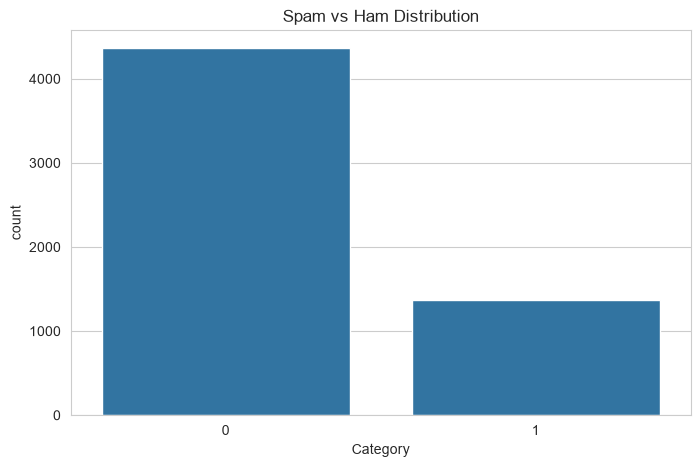

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Category")
plt.title("Spam vs Ham Distribution")
plt.show()

##### Insight

- The dataset contains both spam and ham emails.
- The class distribution appears moderately imbalanced.
- Stratified train-test splitting will be required during model training.

#### <b> Step 4: Email Length Analysis</b>

Email length often differs between spam and legitimate emails.

Long promotional content may indicate spam.

In [7]:
df['EmailLength'] = df["Message"].apply(len)
df['EmailLength'].describe()

count     5728.000000
mean      1556.768680
std       2042.649812
min         13.000000
25%        508.750000
50%        979.000000
75%       1894.250000
max      43952.000000
Name: EmailLength, dtype: float64

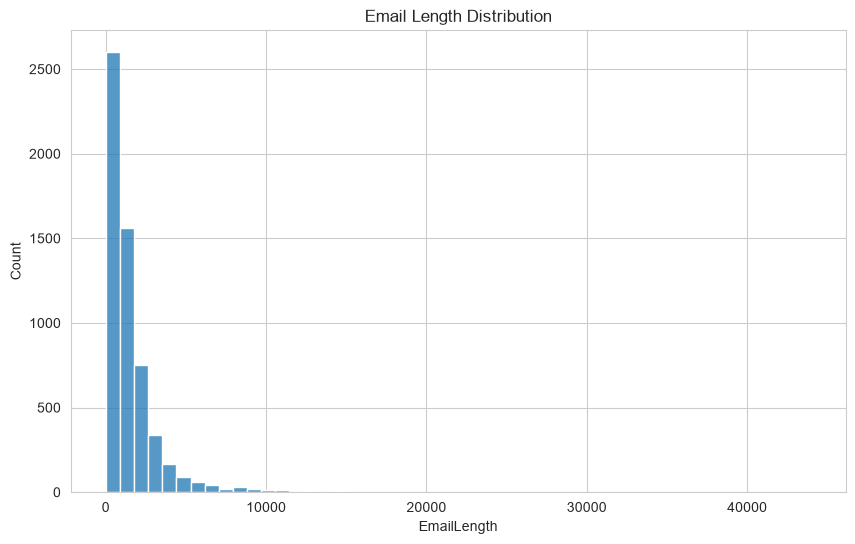

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["EmailLength"],
    bins=50
)

plt.title("Email Length Distribution")

plt.show()

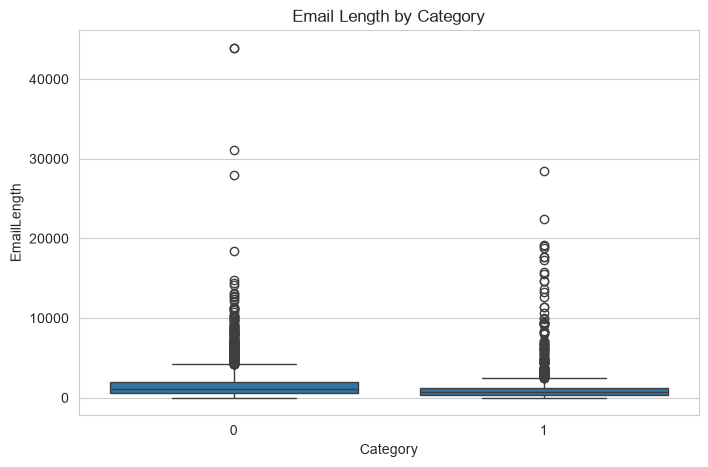

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Category",
    y="EmailLength"
)

plt.title("Email Length by Category")

plt.show()

##### Insight

- Email lengths vary significantly.
- Spam emails tend to have different length characteristics compared to ham emails.
- Email length can be a useful engineered feature.

#### <b>Step 5: Word Count Analysis</b>

##### Word Count Analysis

Word count helps us understand whether spam messages contain more textual content than legitimate messages.

In [10]:
df['WordCount'] = df['Message'].apply(lambda x: len(str(x).split()))

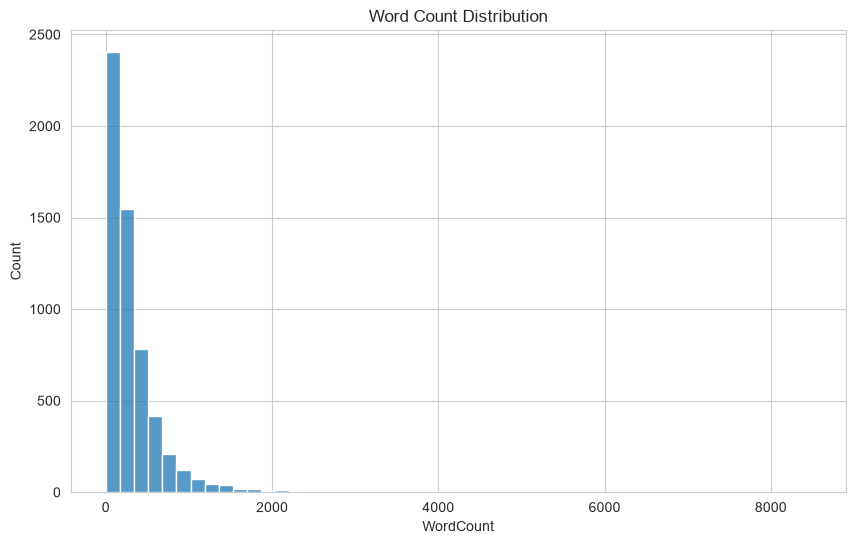

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["WordCount"],
    bins=50
)

plt.title("Word Count Distribution")

plt.show()

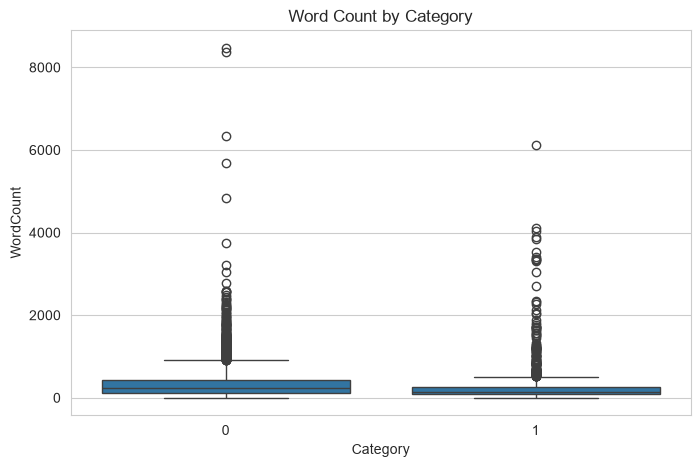

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Category",
    y="WordCount"
)

plt.title("Word Count by Category")

plt.show()

##### Insight

- Spam emails frequently contain large amounts of promotional text.
- Word count appears correlated with email length.
- Word count should be retained during feature engineering.

#### <b>Step 6: Digit Count Analysis</b>

In [13]:
df["DigitCount"] = df["Message"].apply(
    lambda x: sum(
        c.isdigit()
        for c in str(x)
    )
)

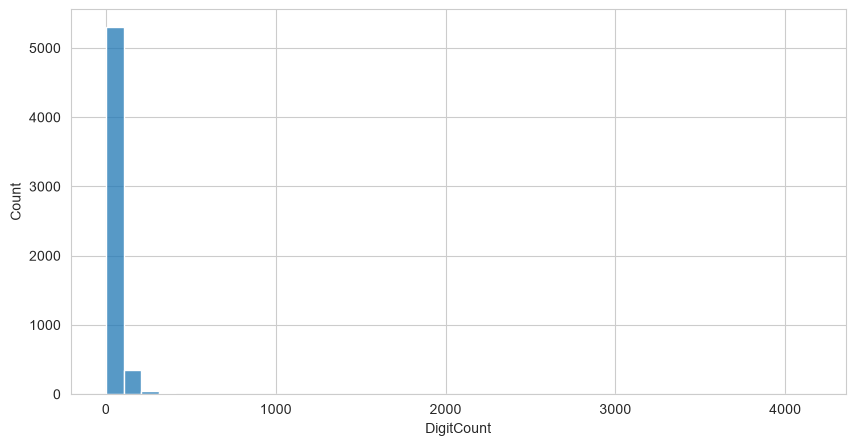

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["DigitCount"],
    bins=40
)

plt.show()

##### Insight

- Spam emails frequently include phone numbers, coupon codes, and prices.
- Digit count may help distinguish spam content.

#### <b>Step 7: Special Character Analysis</b>

In [15]:
df["SpecialCharCount"] = df["Message"].apply(
    lambda x: sum(
        c in string.punctuation
        for c in str(x)
    )
)

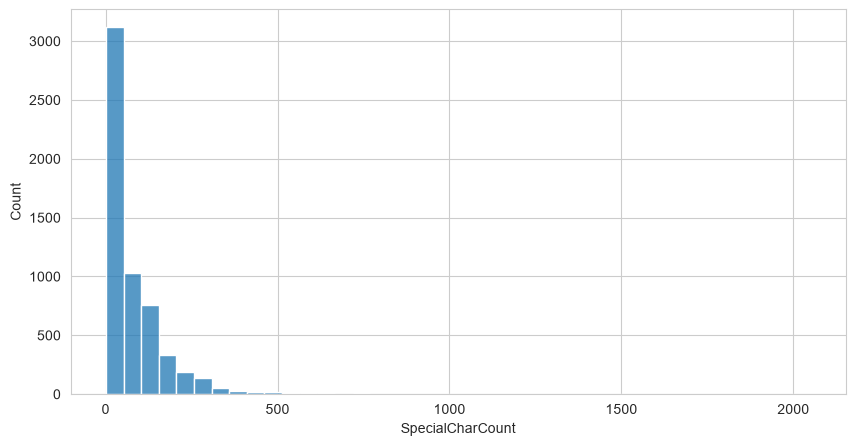

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["SpecialCharCount"],
    bins=40
)

plt.show()

##### Insight

- Spam emails often contain excessive punctuation and symbols.
- This feature may help identify promotional content.

#### <b>Step 8: Correlation Analysis</b>

In [17]:
corr_df = df[
    [
        "EmailLength",
        "WordCount",
        "DigitCount",
        "SpecialCharCount"
    ]
]

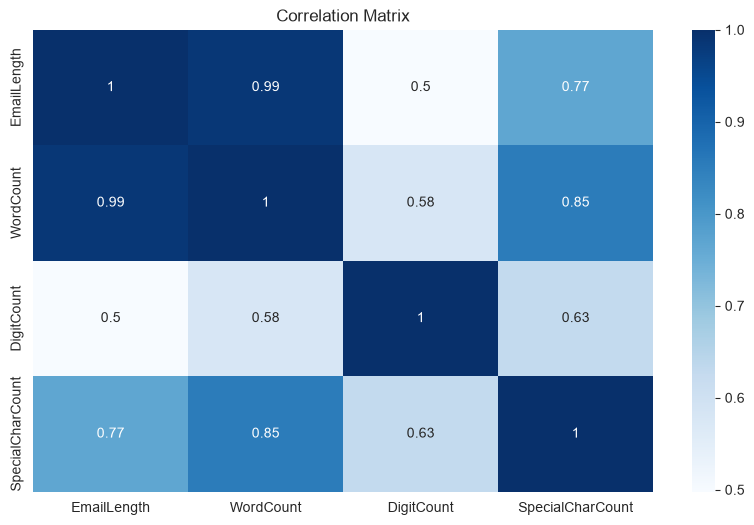

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

##### Insight

- Email length and word count show strong correlation.
- Other features contribute complementary information.
- Multicollinearity appears manageable.

#### <b>Step 9: Top Spam Keywords

In [19]:
spam_text = " ".join(
    df[df["Category"] == 1]
    ["CleanMessage"]
)

spam_words = spam_text.split()

top_spam = Counter(
    spam_words
).most_common(20)

spam_df = pd.DataFrame(
    top_spam,
    columns=["Word","Count"]
)

spam_df

,Word,Count
0,subject,1577
1,compani,1065
2,com,999
3,mail,917
4,busi,897
5,email,865
6,inform,818
7,receiv,727
8,e,698
9,get,694


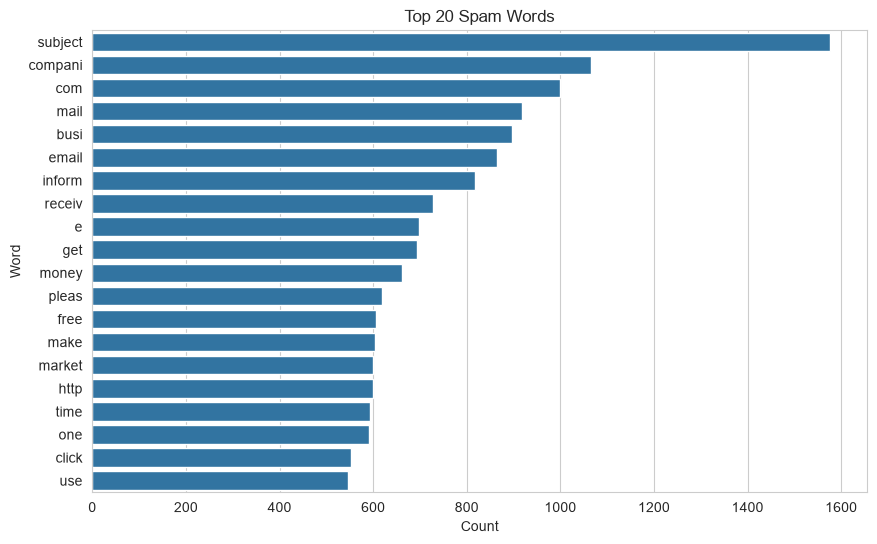

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=spam_df,
    x="Count",
    y="Word"
)

plt.title("Top 20 Spam Words")

plt.show()

##### <b> Spam Word Cloud</b>

Word Clouds help visualize the most frequently occurring words in spam emails.

Larger words indicate higher frequency and greater importance within spam messages.

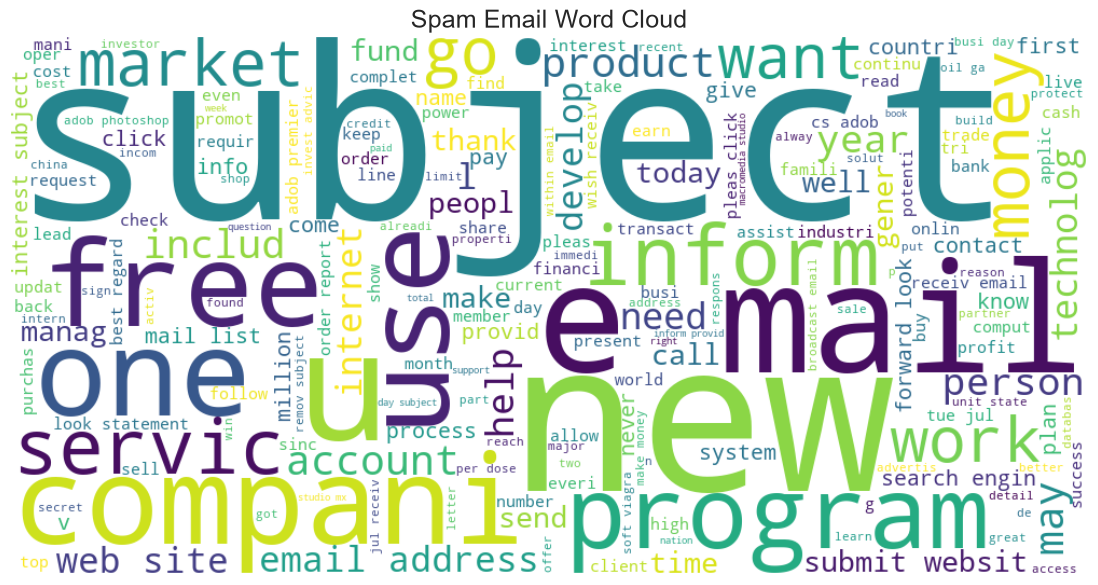

In [21]:
spam_text = " ".join(
    df[df["Category"] == 1]["CleanMessage"]
)

spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(15,7))

plt.imshow(
    spam_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Spam Email Word Cloud",
    fontsize=18
)

plt.show()

##### Insight

- Spam emails contain recurring promotional and marketing terms.
- These words will strongly influence TF-IDF representations.
- Spam emails are dominated by promotional and marketing-related keywords.
- Frequently occurring words indicate common spam tactics such as offers, discounts, rewards, and financial incentives.
- These patterns justify the use of NLP techniques such as TF-IDF vectorization.

#### <b>Step 10: Top Ham Words</b>

In [22]:
ham_text = " ".join(
    df[df["Category"] == 0]
    ["CleanMessage"]
)

ham_words = ham_text.split()

top_ham = Counter(
    ham_words
).most_common(20)

ham_df = pd.DataFrame(
    top_ham,
    columns=["Word","Count"]
)

ham_df

,Word,Count
0,enron,13388
1,ect,11417
2,subject,8625
3,vinc,8531
4,hou,5569
5,kaminski,4801
6,pleas,4494
7,com,4444
8,would,4151
9,cc,3889


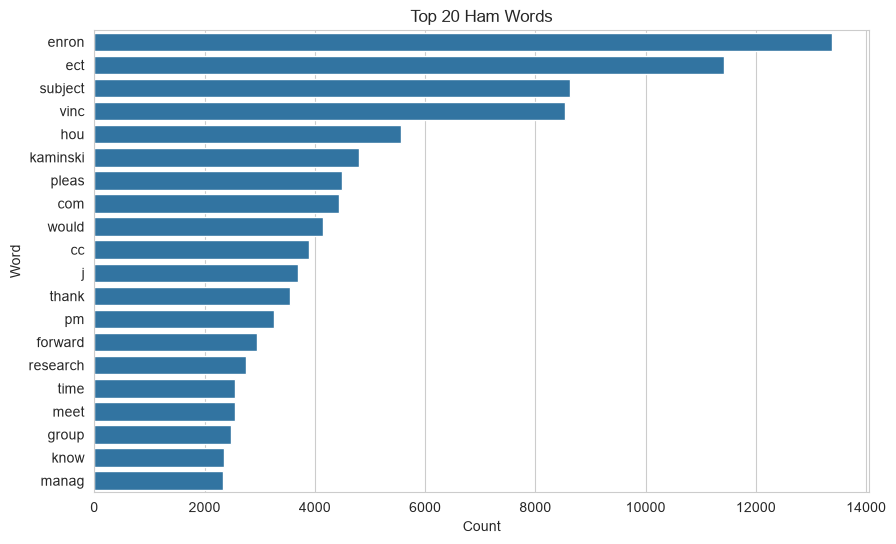

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=ham_df,
    x="Count",
    y="Word"
)

plt.title("Top 20 Ham Words")

plt.show()

##### <b> Ham Word Cloud</b>

This visualization highlights the most common words appearing in legitimate emails.

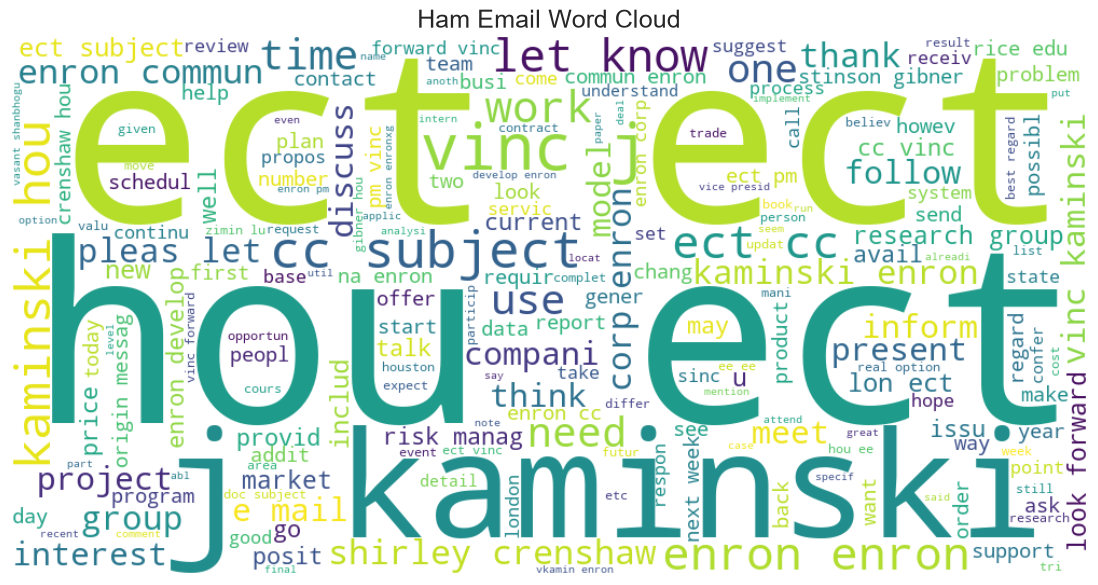

In [24]:
ham_text = " ".join(
    df[df["Category"] == 0]["CleanMessage"]
)

ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(15,7))

plt.imshow(
    ham_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Ham Email Word Cloud",
    fontsize=18
)

plt.show()

##### Insight

- Ham emails contain business and communication-oriented vocabulary.
- These words provide useful signals for classification.
- Ham emails contain communication-oriented vocabulary.
- Common words relate to business discussions, project updates, meetings, and organizational communication.
- The vocabulary differs significantly from spam emails, making textual features highly valuable for classification.

#### <b>CONCLUSION</b>

##### Key Findings

1. The dataset contains both spam and ham emails with moderate class imbalance.

2. Email length and word count differ significantly across classes.

3. Spam emails frequently contain:
   - URLs
   - Promotional keywords
   - Numbers
   - Special characters

4. Ham emails contain more conversational and business-oriented language.

5. Feature engineering should include:
   - EmailLength
   - WordCount
   - URLCount
   - EmailCount
   - DigitCount
   - SpecialCharCount
   - TF-IDF Text Features

##### Next Step

Proceed to Feature Engineering and NLP Vectorization using TF-IDF with N-Grams.

## <b>FEATURE ENGINNERING & NLP VECTORIZATION

### Objective

To prepare the email dataset for machine learning models, several numerical features were engineered from the email text.

Engineered Features:

1. EmailLength
2. WordCount
3. SentenceCount
4. AvgWordLength
5. DigitCount
6. SpecialCharCount

In addition, NLP Vectorization was performed using:

- TF-IDF Vectorizer
- Maximum Features: 5000
- N-Gram Range: (1,2)

This transformation converts textual information into numerical representations that machine learning algorithms can process effectively.

### Why TF-IDF?

TF-IDF (Term Frequency–Inverse Document Frequency):

- Captures important words
- Reduces importance of common words
- Produces sparse numerical vectors
- Works extremely well for spam detection

Expected Output:

- Feature engineered dataset
- Saved TF-IDF vectorizer
- Model-ready features

#### <b> Step 1: NLP Vectorization</b>

##### NLP Vectorization using TF-IDF

Machine learning algorithms cannot understand raw text.

TF-IDF (Term Frequency-Inverse Document Frequency) converts textual information into numerical vectors.

Configuration:

- Vectorizer: TF-IDF
- Max Features: 5000
- N-Gram Range: (1,2)

This approach captures both individual words and word combinations while reducing the influence of common words.

In [25]:
featured_df = pd.read_csv("../data/processed/email_featured.csv")
print("Featured Dataset Shape:",featured_df.shape)

featured_df.head()

Featured Dataset Shape: (5728, 5007)


,Category,EmailLength,WordCount,SentenceCount,AvgWordLength,DigitCount,SpecialCharCount,aa,ab,ab html,...,zadorozhni,ze,zero,zhang,zhendong,zimin,zimin lu,zip,zipter,zone
0,1,1484,324,10,3.527778,3,136,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,598,89,0,5.685393,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,448,87,3,4.057471,10,8,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,500,98,5,4.040816,30,25,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,235,52,9,3.480769,0,13,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Insight

- TF-IDF generated 5000 textual features.
- Combining TF-IDF with handcrafted features provides both semantic and statistical information.
- The resulting dataset is suitable for training machine learning classifiers.

#### <b>Step 2: Feature Engineering Overview</b>

In [26]:
feature_cols = [
    "EmailLength",
    "WordCount",
    "SentenceCount",
    "AvgWordLength",
    "DigitCount",
    "SpecialCharCount"
]

featured_df[feature_cols].head()

,EmailLength,WordCount,SentenceCount,AvgWordLength,DigitCount,SpecialCharCount
0,1484,324,10,3.527778,3,136
1,598,89,0,5.685393,0,1
2,448,87,3,4.057471,10,8
3,500,98,5,4.040816,30,25
4,235,52,9,3.480769,0,13


#### <b> Step 3: Feature Correlation</b>

Correlation analysis helps identify relationships between engineered numerical features.

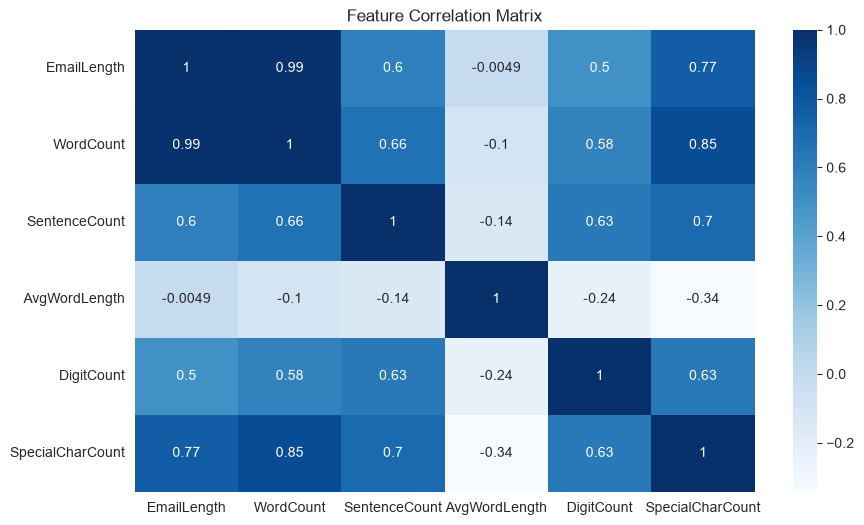

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    featured_df[
        [
            "EmailLength",
            "WordCount",
            "SentenceCount",
            "AvgWordLength",
            "DigitCount",
            "SpecialCharCount"
        ]
    ].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation Matrix")

plt.show()

##### Insight

- EmailLength and WordCount are highly correlated.
- DigitCount and SpecialCharCount provide additional information.
- Multiple engineered features capture different aspects of email structure.

#### <b> CONCLUSION</b>

##### Summary
The dataset was successfully transformed into machine-learning-ready numerical features.

TF-IDF converted text into approximately 5000 numerical features while preserving the importance of informative words.

Additional engineered features such as character count and word count provide extra signals for spam classification.

Created Features:

- EmailLength,
- WordCount,
- SentenceCount,
- AvgWordLength,
- DigitCount,
- SpecialCharCount

TF-IDF Vectorization:

- Top 5000 vocabulary terms
- Sparse numerical representation
- Saved vectorizer for production deployment

Output Files:

- email_featured.csv
- tfidf_vectorizer.pkl

Next Step:

Model Preparation & Train/Test Split